In [1]:
# Minimal imports
from ladder.data import get_data # Needed to grab data
from ladder.scripts import CrossConditionWorkflow # Our workflow object to run the cross-conditional model
import umap, torch, pyro # To set seeds + umaps
import torch.optim as opt # For defining out optimizer


# For plotting
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from umap import UMAP

# For data loading
import anndata as ad
import scanpy as sc

# Set up plots
import os
os.makedirs('plots', exist_ok=True)



cell_colors = {
 'Endothelial' : "#8B1E3F",  # Deep Burgundy
 'Fibroblast' : "#3B5998",  # Rich Blue
 'Gamma-delta T Cell' : "#6A994E",  # Fresh Olive Green
 'Granulocyte' : "#264653",  # Deep Teal
 'Keratinocyte' : "#E9C46A",  # Soft Yellow
 'Macrophage' : "#F4A261",  # Warm Orange
 'Melanocyte' : "#E76F51",  # Burnt Sienna
 'Neutrophil' : "#FFC8A2",  # Soft Peach
 'Pericyte' : "#D3D9E3",  # Soft Pastel Blue
 'Red Blood Cell' : "#BC4749", # Warm Cranberry Red
 'Skeletal Muscle' : "#A8DADC", # Pale Turquoise
 'T Cell' : "#2A9D8F", # Muted Green
}

time_colors = {
    '0DPW' : "#8DD3C7",
    '4DPW' : "#E6AB02",
    '7DPW' : "#BEBADA",
    'POD7' : "#BEBADA",
    'POD14' : "#80B1D3",
    'POD30' : "#FDB462",
}

age_colors = {
    'Aged' : "#E41A1C",
    'Young' : "#377EB8",
}

treatment_colors = {
    'PBS-treated': "#4DAF4A",
    'Verteporfin-treated': "#984EA3",
}

In [2]:
# Helpers for plotting

# Courtesy of: https://stackoverflow.com/questions/7965743/how-can-i-set-the-aspect-ratio
def force_aspect(ax,aspect=1):
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)



def grab_params(workflow, model, data="Vu"):
    ## Parameters for UMAP
    reducer_base = umap.UMAP(n_neighbors=50, min_dist=0.1, metric="correlation", verbose=False, random_state=42)
    reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, metric="correlation", verbose=False, random_state=42)
    
    ## All data reductions we need for the plots
    
    match model:
        case "Patches":
            base_umap = reducer_base.fit_transform(np.array(workflow.anndata.X.todense()))
            z_umap = reducer.fit_transform(workflow.anndata.obsm['patches_z_latent']) ## Z
            w_umap = reducer.fit_transform(workflow.anndata.obsm['patches_w_latent']) ## W
            rho_umap = reducer.fit_transform(workflow.anndata.obsm['patches_rho_latent']) ## rho
            
            w_pca = sc.pp.pca(workflow.anndata.obsm['patches_w_latent'], random_state=42)[:,:2] ## W PCA, grab first 2 PCs
            z_pca = sc.pp.pca(workflow.anndata.obsm['patches_z_latent'], random_state=42)[:,:2] ## Z PCA, grab first 2 PCs
    
    
            df = pd.DataFrame(base_umap)
            df.index = workflow.anndata.obs.index
            
            df.columns = ["base_1", "base_2"]
            df["z_umap_1"], df["z_umap_2"] = z_umap[:,0], z_umap[:,1]
            df["w_umap_1"], df["w_umap_2"] = w_umap[:,0], w_umap[:,1]
            df["rho_umap_1"], df["rho_umap_2"] = rho_umap[:,0], rho_umap[:,1]
            df["z_pc_1"], df["z_pc_2"] = z_pca[:,0], z_pca[:,1]
            df["w_pc_1"], df["w_pc_2"] = w_pca[:,0], w_pca[:,1]
    
        case "SCANVI":
            base_umap = reducer_base.fit_transform(np.array(workflow.anndata.X.todense()))
            u_umap = reducer.fit_transform(workflow.anndata.obsm['scanvi_u_latent']) ## W
            u_pca = sc.pp.pca(workflow.anndata.obsm['scanvi_u_latent'], random_state=42)[:,:2]
            z_umap = reducer.fit_transform(workflow.anndata.obsm['scanvi_z_latent']) ## W
            z_pca = sc.pp.pca(workflow.anndata.obsm['scanvi_z_latent'], random_state=42)[:,:2]
    
            df = pd.DataFrame(base_umap)
            df.index = workflow.anndata.obs.index
            
            df.columns = ["base_1", "base_2"]
            
            df["u_umap_1"], df["u_umap_2"] = u_umap[:,0], u_umap[:,1]
            df["u_pc_1"], df["u_pc_2"] = u_pca[:,0], u_pca[:,1]
            df["z_umap_1"], df["z_umap_2"] = z_umap[:,0], z_umap[:,1]
            df["z_pc_1"], df["z_pc_2"] = z_pca[:,0], z_pca[:,1]
    
    
        case "SCVI":
            base_umap = reducer_base.fit_transform(np.array(workflow.anndata.X.todense()))
            z_umap = reducer.fit_transform(workflow.anndata.obsm['scvi_latent'])
            z_pca = sc.pp.pca(workflow.anndata.obsm['scvi_latent'], random_state=42)[:,:2] 
    
            df = pd.DataFrame(base_umap)
            df.index = workflow.anndata.obs.index
            
            df.columns = ["base_1", "base_2"]
            df["z_umap_1"], df["z_umap_2"] = z_umap[:,0], z_umap[:,1]
            df["z_pc_1"], df["z_pc_2"] = z_pca[:,0], z_pca[:,1]

        case "Base":
            anndata = workflow.anndata.copy()
            anndata.X = anndata.layers["normalized"]
            
            sc.pp.normalize_total(anndata, target_sum=1e4)
            sc.pp.log1p(anndata)
            sc.tl.pca(anndata, svd_solver="arpack")
            
            base_umap = reducer_base.fit_transform(np.array(anndata.X.todense()))
            base_pca = anndata.obsm['X_pca'][:,:2]

            df = pd.DataFrame(base_umap)
            df.index = anndata.obs.index

            df.columns = ["base_umap_1", "base_umap_2"]
            df["base_pc_1"], df["base_pc_2"] = base_pca[:,0], base_pca[:,1]


    
    match data:
        case "Vu":
            df["broad_type"], df["age"], df["time"], df["factorized"] = workflow.anndata.obs["broad_type"], workflow.anndata.obs["age"], workflow.anndata.obs["time"], workflow.anndata.obs["factorized"]
        case "Mascharak":
            df["broad_type"], df["treatment"], df["time"], df["factorized"] = workflow.anndata.obs["broad_type"], workflow.anndata.obs["treatment"], workflow.anndata.obs["time"], workflow.anndata.obs["factorized"]
            

    return df

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 292M/292M [00:05<00:00, 51.9MB/s]


Object saved at ./data/vu_2022_ay_wh.h5ad


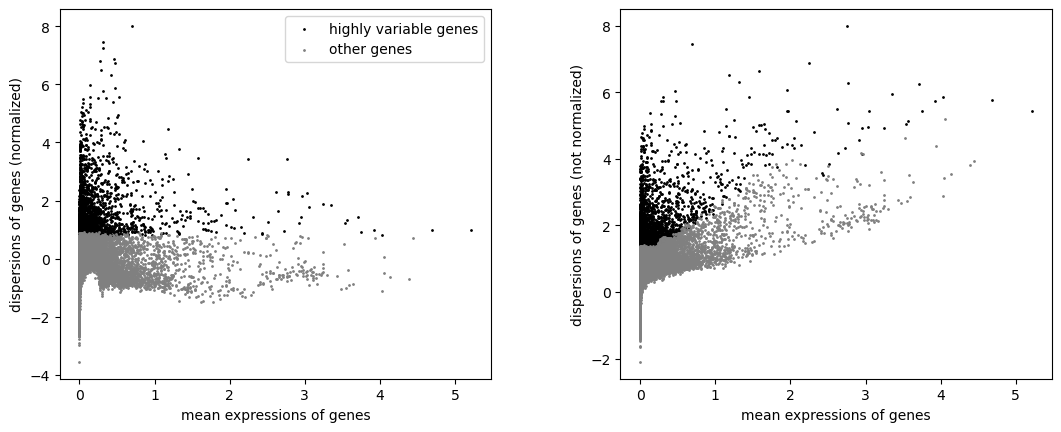

In [3]:
get_data("Vu")

# Load the anndata object
anndata_vu = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
anndata_vu.layers["normalized"] = anndata_vu.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_vu, n_top_genes=3000, batch_key="sample")
sc.pl.highly_variable_genes(anndata_vu)

anndata_vu = anndata_vu[:, anndata_vu.var["highly_variable"]]
anndata_vu.X = anndata_vu.layers["counts"]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36.0M/36.0M [00:00<00:00, 83.5MB/s]


Object saved at ./data/mascharak_2022_tn_wh.h5ad


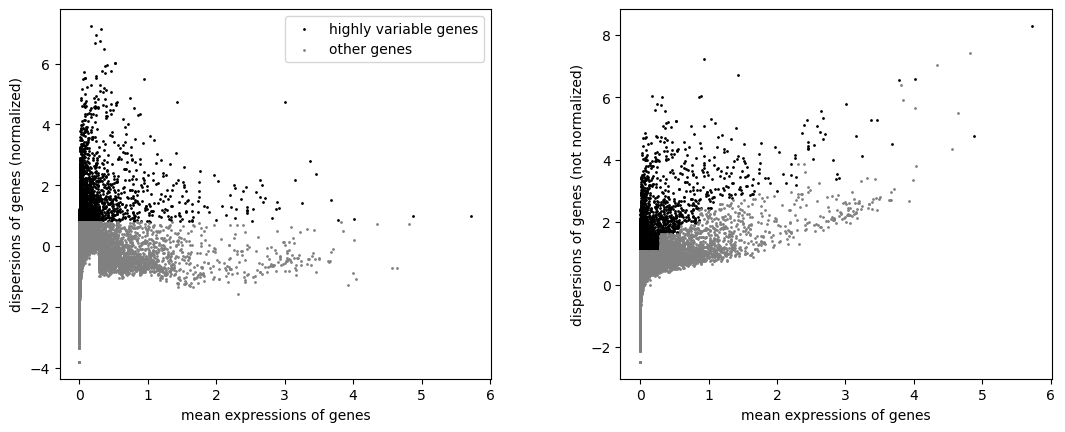

In [4]:
get_data("Mascharak")

# Load the anndata object
anndata_mascharak = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
anndata_mascharak.layers["normalized"] = anndata_mascharak.X

# Find/subset HVGs & swap to raw counts
sc.pp.highly_variable_genes(anndata_mascharak, n_top_genes=3000)
sc.pl.highly_variable_genes(anndata_mascharak)

anndata_mascharak = anndata_mascharak[:, anndata_mascharak.var["highly_variable"]]
anndata_mascharak.X = anndata_mascharak.layers["counts"]

In [5]:
workflow_mascharak = CrossConditionWorkflow(anndata_mascharak, verbose=True, random_seed=42)
factors_mascharak = ["time", "treatment", "broad_type"]
workflow_mascharak.prep_model(factors_mascharak, cell_type_label_key="broad_type", model_type='Patches')
workflow_mascharak.load_model('params/patches_mascharak')



workflow_vu = CrossConditionWorkflow(anndata_vu, verbose=True, random_seed=42)
factors_vu = ["time", "age", "broad_type"]
workflow_vu.prep_model(factors_vu, batch_key="sample", cell_type_label_key="broad_type", model_type='Patches')
workflow_vu.load_model('params/patches_vu')

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run cross-condition model.

Condition classes : ['time', 'treatment', 'broad_type']
Number of attributes per class : [3, 2, 9]

Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': False, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 14, 'len_attrs': [3, 2, 9]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run cross-condition model.

Condition classes : ['time', 'age', 'broad_type']
Number of attributes per class : [3, 2, 10]

Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': True, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 15, 'len_attrs': [3, 2, 10]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}


In [6]:
workflow_vu.write_embeddings()
workflow_mascharak.write_embeddings()

df_patches_vu = grab_params(workflow_vu, "Patches", "Vu")
df_base_vu = grab_params(workflow_vu, "Base", "Vu")

df_patches_mascharak = grab_params(workflow_mascharak, "Patches", "Mascharak")
df_base_mascharak = grab_params(workflow_mascharak, "Base", "Mascharak")

df_patches_vu['id'] = df_patches_vu.index
df_patches_mascharak['id'] = df_patches_mascharak.index

Written embeddings to object 'anndata.obsm' under workflow.
Written embeddings to object 'anndata.obsm' under workflow.


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/mi

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/insomnia001/depts/morpheus/users/ob2391/mi

/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/tmp/ipykernel_1310609/2244004576.py:65: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:
/tmp/ipykernel_1310609/2244004576.py:69: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:
/tmp/ipykernel_1310609/2244004576.py:73: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:
/tmp/ipykernel_1310609/2244004576.py:77: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:
/tmp/ipykernel_1310609/2244004576.py:81: MatplotlibD

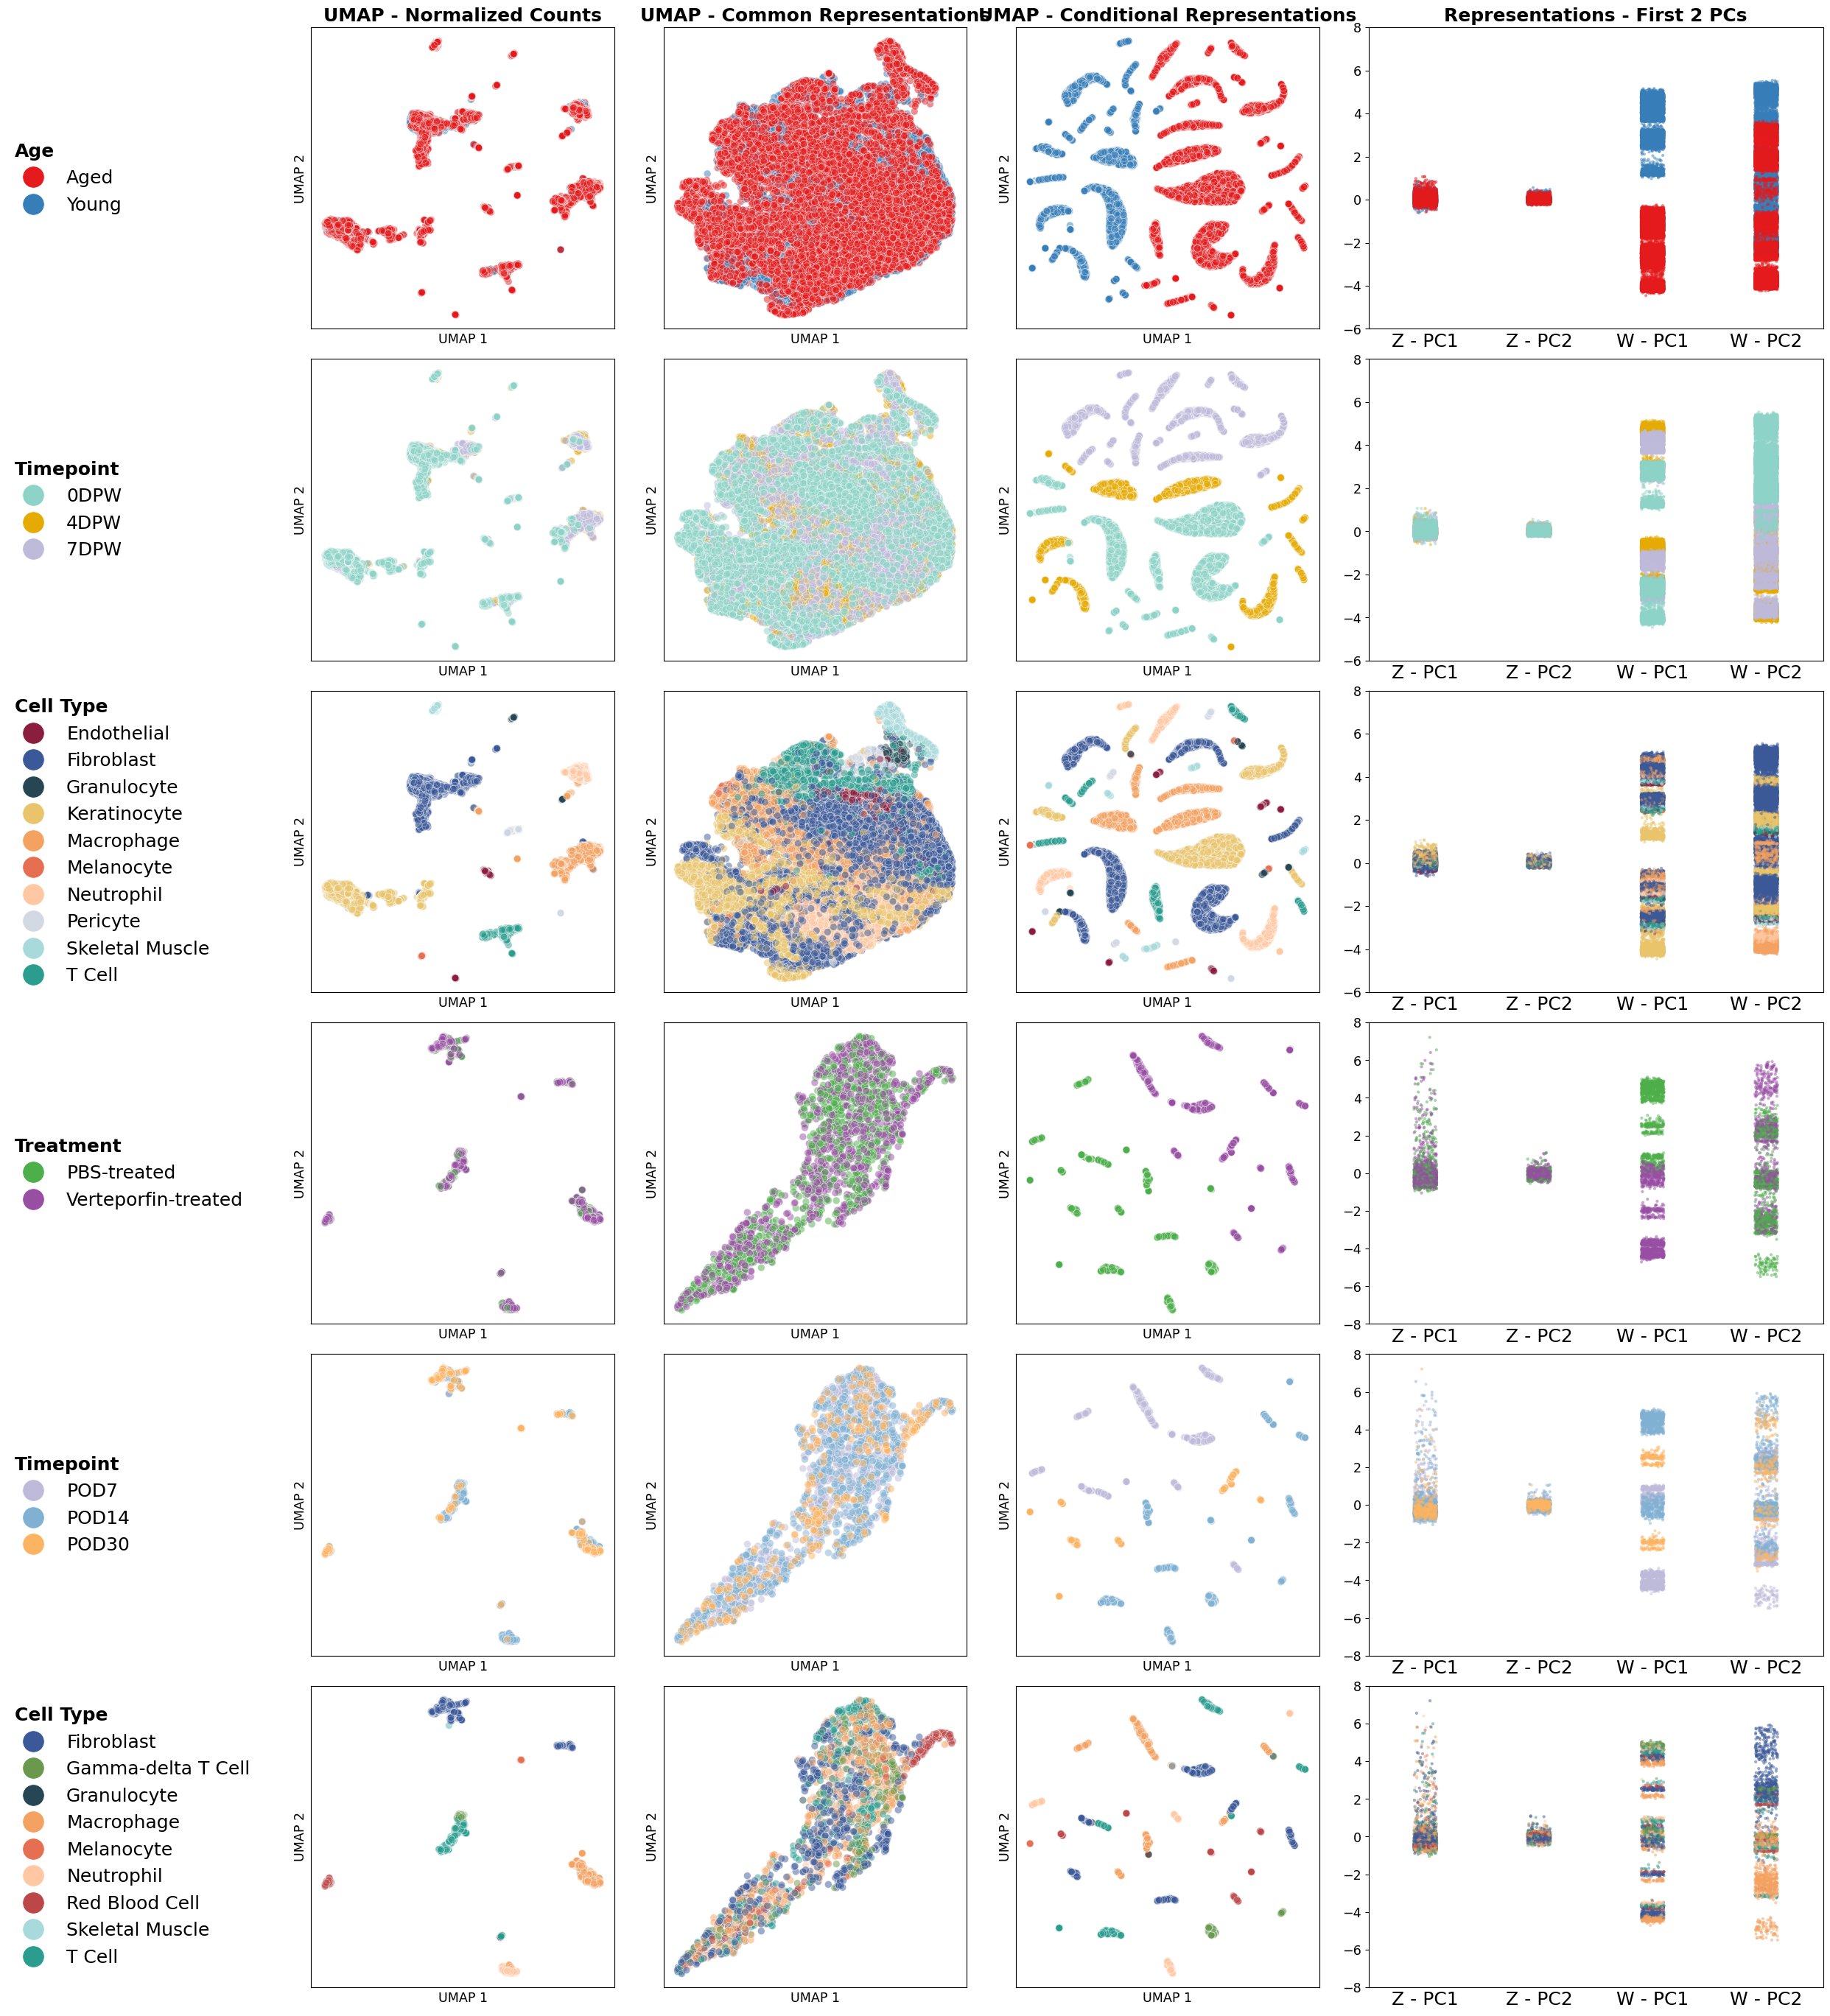

In [7]:
# Figure skeleton

fontsize=18
alpha=0.5
s=50
s_strip=3
figscale = 3.5
leg_bbox = (-1.9, 0.5)


# Gridspec
fig = plt.figure(figsize=(21 * 1/2.54 * figscale, 25.08 * 1/2.54 * figscale))
gs = gridspec.GridSpec(6, 5, wspace=0.17, hspace = 0.1, figure=fig, width_ratios=[0.3,1,1,1,1.5])
ax = [fig.add_subplot(gs[i//5, i%5]) for i in range(30)]


# Figures PC
melted_vu = pd.melt(df_patches_vu, id_vars=['id', 'age', 'time', 'broad_type'], value_vars=['z_pc_1', 'z_pc_2', 'w_pc_1', 'w_pc_2'])
melted_mascharak = pd.melt(df_patches_mascharak, id_vars=['id', 'treatment', 'time', 'broad_type'], value_vars=['z_pc_1', 'z_pc_2', 'w_pc_1', 'w_pc_2'])
## Vu strips
sns.stripplot(melted_vu, x = 'variable', y = "value", hue='age', alpha=alpha, s=s_strip, ax=ax[4], legend=False, palette=age_colors)
sns.stripplot(melted_vu, x = 'variable', y = "value", hue='time', alpha=alpha, s=s_strip, ax=ax[9], legend=False, palette=time_colors)
sns.stripplot(melted_vu, x = 'variable', y = "value", hue='broad_type', alpha=alpha, s=s_strip, ax=ax[14], legend=False, palette=cell_colors)
## Mascharak Strips
sns.stripplot(melted_mascharak, x = 'variable', y = "value", hue='treatment', alpha=alpha, s=s_strip, ax=ax[19], legend=False, palette=treatment_colors)
sns.stripplot(melted_mascharak, x = 'variable', y = "value", hue='time', alpha=alpha, s=s_strip, ax=ax[24], legend=False, palette=time_colors)
sns.stripplot(melted_mascharak, x = 'variable', y = "value", hue='broad_type', alpha=alpha, s=s_strip, ax=ax[29], legend=False, palette=cell_colors)


# UMAPs
##Counts
age_vu = sns.scatterplot(df_base_vu, x='base_umap_1', y='base_umap_2', ax=ax[1], hue = 'age', palette=age_colors, s=s, alpha=alpha)
time_vu = sns.scatterplot(df_base_vu, x='base_umap_1', y='base_umap_2', ax=ax[6], hue = 'time', palette=time_colors, s=s, alpha=alpha)
ct_vu = sns.scatterplot(df_base_vu, x='base_umap_1', y='base_umap_2', ax=ax[11], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha)
trt_mascharak = sns.scatterplot(df_base_mascharak, x='base_umap_1', y='base_umap_2', ax=ax[16], hue = 'treatment', palette=treatment_colors, s=s, alpha=alpha)
time_mascharak = sns.scatterplot(df_base_mascharak, x='base_umap_1', y='base_umap_2', ax=ax[21], hue = 'time', palette=time_colors, s=s, alpha=alpha)
ct_mascharak = sns.scatterplot(df_base_mascharak, x='base_umap_1', y='base_umap_2', ax=ax[26], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha)
##Zs
sns.scatterplot(df_patches_vu, x='z_umap_1', y='z_umap_2', ax=ax[2], hue = 'age', palette=age_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_vu, x='z_umap_1', y='z_umap_2', ax=ax[7], hue = 'time', palette=time_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_vu, x='z_umap_1', y='z_umap_2', ax=ax[12], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='z_umap_1', y='z_umap_2', ax=ax[17], hue = 'treatment', palette=treatment_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='z_umap_1', y='z_umap_2', ax=ax[22], hue = 'time', palette=time_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='z_umap_1', y='z_umap_2', ax=ax[27], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha, legend=False)
##Ws
sns.scatterplot(df_patches_vu, x='w_umap_1', y='w_umap_2', ax=ax[3], hue = 'age', palette=age_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_vu, x='w_umap_1', y='w_umap_2', ax=ax[8], hue = 'time', palette=time_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_vu, x='w_umap_1', y='w_umap_2', ax=ax[13], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='w_umap_1', y='w_umap_2', ax=ax[18], hue = 'treatment', palette=treatment_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='w_umap_1', y='w_umap_2', ax=ax[23], hue = 'time', palette=time_colors, s=s, alpha=alpha, legend=False)
sns.scatterplot(df_patches_mascharak, x='w_umap_1', y='w_umap_2', ax=ax[28], hue = 'broad_type', palette=cell_colors, s=s, alpha=alpha, legend=False)


# Legends
##Metadata
h_age_vu, l_age_vu = age_vu.get_legend_handles_labels()
h_time_vu, l_time_vu = time_vu.get_legend_handles_labels()
h_ct_vu, l_ct_vu = ct_vu.get_legend_handles_labels()
h_trt_mascharak, l_trt_mascharak = trt_mascharak.get_legend_handles_labels()
h_time_mascharak, l_time_mascharak = time_mascharak.get_legend_handles_labels()
h_ct_mascharak, l_ct_mascharak = ct_mascharak.get_legend_handles_labels()

##Legends
leg = ax[0].legend(h_age_vu, l_age_vu, fontsize=fontsize, markerscale=3, title='Age', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)

leg = ax[5].legend(h_time_vu, l_time_vu, fontsize=fontsize, markerscale=3, title='Timepoint', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = ax[10].legend(h_ct_vu, l_ct_vu, fontsize=fontsize, markerscale=3, title='Cell Type', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = ax[15].legend(h_trt_mascharak, l_trt_mascharak, fontsize=fontsize, markerscale=3, title='Treatment', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = ax[20].legend(h_time_mascharak, l_time_mascharak, fontsize=fontsize, markerscale=3, title='Timepoint', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    
leg = ax[25].legend(h_ct_mascharak, l_ct_mascharak, fontsize=fontsize, markerscale=3, title='Cell Type', title_fontproperties={'weight' : 'bold', 'size' : fontsize}, frameon=False, ncol=1, bbox_to_anchor=leg_bbox, loc='center left', alignment='left')
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    


# Post-edits
for i in range(30):
    if i % 5 in [0,1,2,3]:
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].set_yticklabels([])
        ax[i].set_xticklabels([])

        if i % 5 != 0:
            ax[i].set_xlabel('UMAP 1', fontsize=fontsize * 0.7)
            ax[i].set_ylabel('UMAP 2', fontsize=fontsize * 0.7)

            if i % 5 == 1:
                ax[i].legend([],[],frameon=False)
        
        else:
            ax[i].axis('off')


    elif i%5 == 4:
        ax[i].set_ylabel(None, fontsize=fontsize)
        ax[i].set_xlabel(None)
        ax[i].set_xticks(list(range(4)))
        ax[i].set_xticklabels(['Z - PC1', 'Z - PC2', 'W - PC1', 'W - PC2'], fontsize=fontsize)
        ax[i].tick_params(axis='x', length=0)
        ax[i].set_yticks(ax[i].get_yticks())
        ax[i].set_yticklabels(ax[i].get_yticklabels(), fontsize=fontsize * 0.7)
        


ax[1].set_title('UMAP - Normalized Counts', fontsize=fontsize, weight='bold')
ax[2].set_title('UMAP - Common Representations', fontsize=fontsize, weight='bold')
ax[3].set_title('UMAP - Conditional Representations', fontsize=fontsize, weight='bold')
ax[4].set_title('Representations - First 2 PCs', fontsize=fontsize, weight='bold')



plt.savefig('plots/final/fig_3.png', dpi=300, bbox_inches='tight')
plt.show()